## Создание датасета на основе открытых источников

In [106]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
# np.random.seed(42)
device_dist = {'mobile': 0.68, 'desktop': 0.32}

[Статистика СберСтрахования](https://sberbankins.ru/about/news/sberstrakhovanie-zastrakhovala-17-mln-chelovek-za-10-let-/)

In [107]:
total_contracts_10y = 25200000
mortage_share = 0.66
market_share = 0.35
one_in_four_martage = 0.25

[Информация о тарифах](https://online.sberbankins.ru/store/any-cases-online/assets/documents/ЗЛС_сайт_Полис.pdf#13#6)

In [108]:
tariff_constructive_stone = 0.0023
tariff_constructive_wood = 0.0045
tariff_life_min = 0.0028
tarif_title = 0.0035
online_discount = 0.92 # скидка за оформление онлайн

Конверсии

In [109]:
funnel_rates = {
    'impression': 1.0,
    'click': 0.42,
    'form_start': 0.31,
    'form_complete': 0.24,
    'price_view': 0.19,
    'payment_start': 0.13,
    'paid': 0.085
}

Сезонность

In [110]:
seasonality = {
    1: 0.7, 
    2: 0.8,
    3: 1.1,
    4: 1.2,
    5: 1.3, 
    6: 1.1,
    7: 0.6,
    8: 0.5,
    9: 1.0,
    10: 1.1,
    11: 1.2,
    12: 0.9
}

Примерное распределение по регионам

In [111]:
regions = {
    'Москва': {'share': 0.35, 'avg_mortgage': 8_500_000, 'conversion_boost': 1.1},
    'Санкт-Петербург': {'share': 0.15, 'avg_mortgage': 6_200_000, 'conversion_boost': 1.05},
    'Регионы-млн': {'share': 0.30, 'avg_mortgage': 4_100_000, 'conversion_boost': 0.95},
    'Регионы-прочие': {'share': 0.20, 'avg_mortgage': 2_800_000, 'conversion_boost': 0.85}
}

Различные сценарии возникновения проблем

In [112]:
scenarios = ['baseline', 'mobile_crisis', 'summer_drop', 'price_shock', 'tech_outage']
scenario = np.random.choice(scenarios)

In [113]:
def generate_user(user_id, base_date, scenario='baseline'):
    region = np.random.choice(list(regions.keys()), p=[r['share'] for r in regions.values()])
    device = np.random.choice(list(device_dist.keys()), p=list(device_dist.values()))
    month = np.random.randint(1, 13)
    date = base_date + timedelta(days=np.random.randint(0, 365 * 2))
    current_stage = 'impression'
    stages_order = list(funnel_rates.keys())
    drop_reason = None
    reasons_map = {
        'click': ['Не заинтересовал заголовок', 'Ушёл по сравнению на banki.ru / sravni.ru'],
        'form_start': ['Сложная форма', 'Передумал страховать'],
        'form_complete': ['Долго грузилось', 'Техническая ошибка'],
        'price_view': ['Дорого', 'Нашёл дешевле у конкурента', 'Не понял, что входит'],
        'payment_start': ['Проблема с картой', 'Передумал в последний момент']
    }

    for i, stage in enumerate(stages_order[1:], 1):
        base_prob = funnel_rates[stage] / funnel_rates[stages_order[i-1]]

        if scenario == 'mobile_crisis' and device == 'mobile' and stage in ['form_start', 'form_complete']:
            base_prob *= 0.55  # критический отвал на мобильных
            
        elif scenario == 'summer_drop' and month in [7, 8] and stage == 'price_view':
            base_prob *= 0.50  # летний спад на этапе цены
            
        elif scenario == 'price_shock' and stage == 'price_view':
            base_prob *= 0.60  # общий отвал из-за цены
            if np.random.random() < 0.70:
                drop_reason = 'Дорого'
                
        elif scenario == 'tech_outage' and stage == 'form_complete':
            base_prob *= 0.40  # технические проблемы формы
            if np.random.random() < 0.80:
                drop_reason = 'Техническая ошибка'

        # Базовые корректировки
        if device == 'mobile' and stage in ['form_start', 'form_complete']:
            base_prob *= 0.85
        if month in [7, 8] and stage == 'price_view':
            base_prob *= 0.75
        base_prob *= regions[region]['conversion_boost']

        if np.random.random() < min(base_prob, 1.0):
            current_stage = stage
        else:
            if drop_reason is None and stage in reasons_map:
                drop_reason = np.random.choice(reasons_map[stage])
            elif drop_reason is None:
                drop_reason = 'Технический сбой'
            break

    mortgage_amount, premium, policy_type = None, None, None
    if current_stage == 'paid':
        avg_mort = regions[region]['avg_mortgage']
        mortgage_amount = max(1_500_000, np.random.lognormal(mean=np.log(avg_mort), sigma=0.4))
        
        if np.random.random() < 0.66:
            policy_type = 'mortgage_constructive'
            tariff = tariff_constructive_stone if np.random.random() < 0.85 else tariff_constructive_wood
        elif np.random.random() < 0.8:
            policy_type = 'mortgage_life'
            tariff = np.random.uniform(tariff_life_min, tariff_life_min + 0.003)
        else:
            policy_type = 'mortgage_title'
            tariff = tarif_title
            
        premium = mortgage_amount * tariff
        if np.random.random() < 0.78:
            premium *= online_discount
        premium = round(premium, 2)
        mortgage_amount = round(mortgage_amount, 2)

    return {
        'user_id': f"USER_{user_id:06d}",
        'session_id': f"SES_{np.random.randint(10**8, 10**9)}",
        'date': date.strftime('%Y-%m-%d'),
        'month': month,
        'region': region,
        'device': device,
        'funnel_stage': current_stage,
        'drop_reason': drop_reason,
        'mortgage_amount': mortgage_amount,
        'policy_type': policy_type,
        'premium_rub': premium,
        'is_online': premium is not None and premium < mortgage_amount * (tariff_constructive_stone + 0.0001),
        'days_to_decision': np.random.randint(0, 14) if current_stage == 'paid' else None
    }

In [114]:
base_date = datetime(2024, 1, 1)
data = [generate_user(i, base_date, scenario=scenario) for i in range(50000)]
df = pd.DataFrame(data)

df['generated_scenario'] = scenario

df['date'] = pd.to_datetime(df['date'])
df['week'] = df['date'].dt.isocalendar().week
df['is_converted'] = (df['funnel_stage'] == 'paid').astype(int)
df['is_dropped'] = (~df['funnel_stage'].isin(['impression', 'paid'])).astype(int)

df.to_csv('sber_mortgage_insurance_funnel.csv', index=False)
df.head()

,user_id,session_id,date,month,region,device,funnel_stage,drop_reason,mortgage_amount,policy_type,premium_rub,is_online,days_to_decision,generated_scenario,week,is_converted,is_dropped
0,USER_000000,SES_959092673,2025-11-23,4,Регионы-прочие,mobile,click,Передумал страховать,NaN,None,NaN,False,NaN,baseline,47,0,1
1,USER_000001,SES_883446053,2025-02-02,4,Регионы-прочие,mobile,form_start,Техническая ошибка,NaN,None,NaN,False,NaN,baseline,5,0,1
2,USER_000002,SES_546602090,2025-08-28,12,Регионы-млн,mobile,impression,Ушёл по сравнению на banki.ru / sravni.ru,NaN,None,NaN,False,NaN,baseline,35,0,0
3,USER_000003,SES_158413338,2024-02-24,2,Регионы-млн,desktop,impression,Не заинтересовал заголовок,NaN,None,NaN,False,NaN,baseline,8,0,0
4,USER_000004,SES_700762008,2025-07-11,2,Москва,mobile,payment_start,Технический сбой,NaN,None,NaN,False,NaN,baseline,28,0,1


Добавляем агрегированные метрики

Структура датасета

| Колонка | Тип данных | Описание | Пример значения |
| :--- | :--- | :--- | :--- |
| `user_id` | `str` | Уникальный анонимизированный идентификатор пользователя | `USR_000123` |
| `session_id` | `str` | ID сессии для трекинга повторных визитов и пути клиента | `SES_482910384` |
| `date` | `date` | Дата взаимодействия с продуктом | `2024-05-17` |
| `month` | `int` | Номер месяца (1–12) для анализа сезонности | `5` |
| `week` | `int` | Номер недели по ISO для недельной агрегации | `21` |
| `region` | `str` | Географический регион пользователя | `Москва`, `Регионы-млн` |
| `device` | `str` | Тип устройства, с которого совершено действие | `mobile`, `desktop` |
| `funnel_stage` | `str` | Текущий этап воронки продаж | `impression`, `click`, `form_complete`, `paid` |
| `drop_reason` | `str` | Предполагаемая причина отказа (если не дошёл до оплаты) | `Дорого`, `Сложная форма` |
| `mortgage_amount` | `float` | Сумма ипотечного кредита (заполняется только для купивших) | `7850000.00` |
| `policy_type` | `str` | Тип оформленного страхового продукта | `mortgage_constructive`, `mortgage_life` |
| `premium_rub` | `float` | Итоговая стоимость полиса в рублях | `18055.00` |
| `is_online` | `bool` | Оформление через онлайн-канал (ДомКлик / СБОЛ) | `True`, `False` |
| `days_to_decision` | `int` | Дней от первого визита до покупки | `3` |
| `is_converted` | `int` | Бинарный флаг: `1` — покупка совершена, `0` — нет | `1` |
| `is_dropped` | `int` | Бинарный флаг: `1` — отвал на промежуточном этапе, `0` — нет | `0` |

In [115]:
funnel_agg = df.groupby('funnel_stage').agg({
    'user_id': 'count',
    'is_converted': 'sum',
    'premium_rub': ['mean', 'sum']
}).round(2)

metrics_summary = pd.DataFrame({
    'metric': [
        'Total impressions',
        'Total converted',
        'Overall conversion rate, %',
        'Average premium (paid only), RUB',
        'Total GWP (Gross Written Premium), RUB',
        'Share of online purchases, %',
        'Top drop reason'
    ],
    'value': [
        len(df),
        df['is_converted'].sum(),
        df['is_converted'].mean() * 100,
        df[df['is_converted'] == 1]['premium_rub'].mean(),
        df[df['is_converted'] == 1]['premium_rub'].sum(),
        df[df['is_converted'] == 1]['is_online'].mean() * 100,
        df[df['drop_reason'].notna()]['drop_reason'].mode().values[0] if len(df[df['drop_reason'].notna()]) > 0 else 'N/A'
    ]
})

metrics_summary.to_csv('metrics_summary.csv', index=False)

| Значение `metric` | Тип `value` | Описание | Пример `value` |
| :--- | :--- | :--- | :--- |
| `Total impressions` | `int` | Общее количество пользователей на входе в воронку | `50000` |
| `Total converted` | `int` | Количество пользователей, купивших полис | `4250` |
| `Overall conversion rate, %` | `float` | Общая конверсия воронки в процентах | `8.52` |
| `Average premium (paid only), RUB` | `float` | Средний чек по оплаченным полисам | `18245.67` |
| `Total GWP (Gross Written Premium), RUB` | `float` | Суммарные страховые премии (сборы) | `77544095.50` |
| `Share of online purchases, %` | `float` | Доля полисов, оформленных онлайн | `78.3` |
| `Top drop reason` | `str` | Самая частая причина отказа от покупки | `Дорого` |

In [116]:
metrics_summary

,metric,value
0,Total impressions,50000
1,Total converted,3743
2,"Overall conversion rate, %",7.486
3,"Average premium (paid only), RUB",21870.228165
4,"Total GWP (Gross Written Premium), RUB",81860264.02
5,"Share of online purchases, %",57.119957
6,Top drop reason,Не заинтересовал заголовок


Воронка в абсолютных числах

In [117]:
print(df['drop_reason'].value_counts(normalize=True).head(10))

drop_reason
Не заинтересовал заголовок                   0.315282
Ушёл по сравнению на banki.ru / sravni.ru    0.310807
Сложная форма                                0.074173
Передумал страховать                         0.073697
Долго грузилось                              0.044901
Техническая ошибка                           0.043669
Технический сбой                             0.038351
Проблема с картой                            0.025510
Передумал в последний момент                 0.025142
Нашёл дешевле у конкурента                   0.016949
Name: proportion, dtype: float64


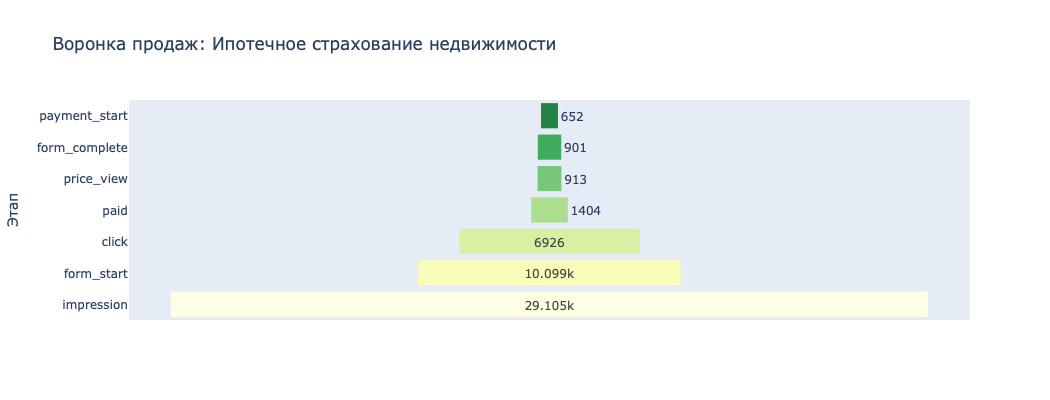

In [101]:
funnel_counts = df.groupby('funnel_stage')['user_id'].nunique().sort_values(ascending = False)
df_plot = pd.DataFrame({
    'Этап': funnel_counts.index,
    'Количество': funnel_counts.values
})

fig_funnel = px.funnel(
    df_plot,
    x='Количество', 
    y='Этап',
    title='Воронка продаж: Ипотечное страхование недвижимости',
    color='Этап',
    color_discrete_sequence=px.colors.sequential.YlGn
)

fig_funnel.update_layout(height=400, showlegend=False)
fig_funnel.show()

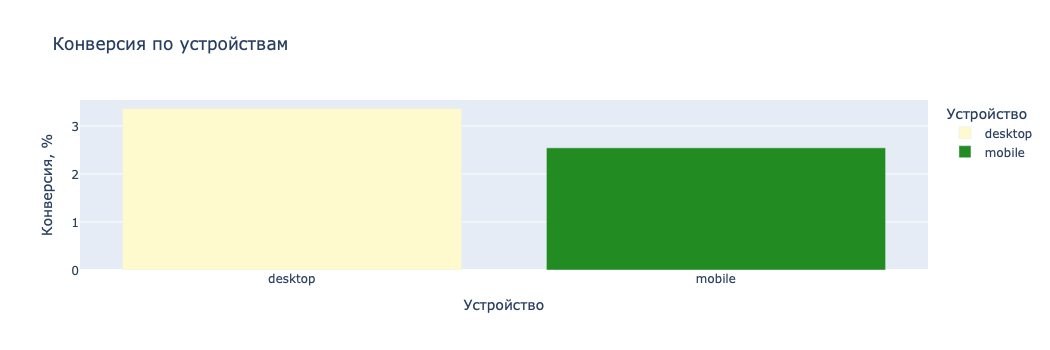

In [102]:
device_conv = df.groupby('device').apply(
    lambda x: (x['funnel_stage'] == 'paid').sum() / len(x) * 100
).reset_index(name='conversion_rate')

fig_device = px.bar(
    device_conv, x='device', y='conversion_rate', color='device',
    title='Конверсия по устройствам',
    labels={'conversion_rate': 'Конверсия, %', 'device': 'Устройство'},
    color_discrete_map={'mobile': 'ForestGreen', 'desktop': 'LemonChiffon'}
)
fig_device.update_layout(height=350)
fig_device.show()

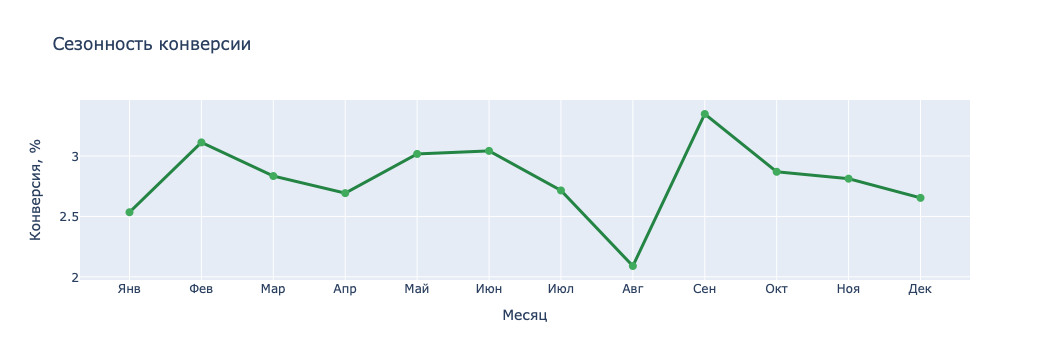

In [103]:
monthly_conv = df.groupby('month').apply(
    lambda x: (x['funnel_stage'] == 'paid').sum() / len(x) * 100
).reset_index(name='conversion_rate')

fig_season = px.line(
    monthly_conv, x='month', y='conversion_rate', markers=True,
    title='Сезонность конверсии',
    labels={'month': 'Месяц', 'conversion_rate': 'Конверсия, %'}
)
fig_season.update_xaxes(tickvals=list(range(1,13)), ticktext=[
    'Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек'
])
fig_season.update_traces(line=dict(color='#238443', width=3), marker=dict(size=8, color='#41ab5d'))
fig_season.show()

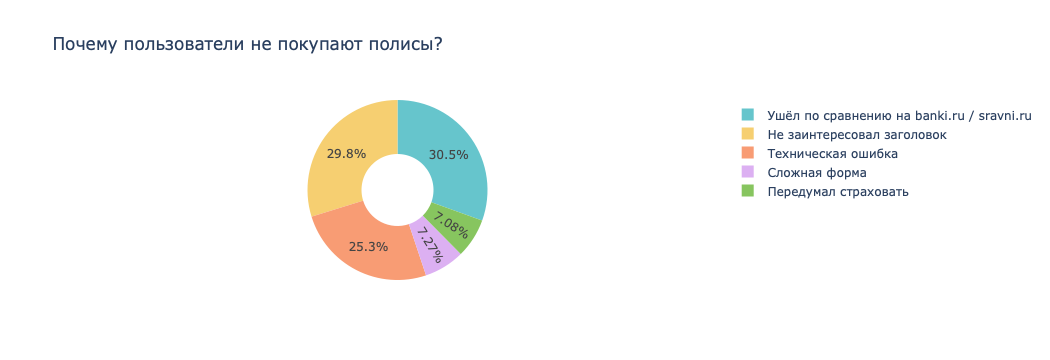

In [104]:
drop_reasons = df[df['drop_reason'].notna()]['drop_reason'].value_counts().head(5)

fig_reasons = px.pie(
    names=drop_reasons.index, values=drop_reasons.values,
    title='Почему пользователи не покупают полисы?',
    hole=0.4, color_discrete_sequence=px.colors.qualitative.Pastel
)
fig_reasons.show()

recommendations = {
    'Дорого': 'Показывать цену как "от 230 ₽/мес" вместо годовой суммы',
    'Сложная форма': 'Упростить ввод данных, добавить автозаполнение',
    'Не понял, что входит': 'Добавить тултипы и краткий чеклист покрытия',
    'Нашёл дешевле': 'Подсветить преимущества Сбера: скорость, интеграция с ипотекой',
    'Техническая ошибка': 'Мониторинг ошибок + ускорение загрузки'
}